In [ ]:
# %env SM_FRAMEWORK=tf.keras

In [ ]:
 %pip install numpy==1.21

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [1]:
 %pip install tensorflow --upgrade

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
 %pip install keras --upgrade

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [3]:
 %pip install -U segmentation-models --upgrade

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 KB 6.7 MB/s eta 0:00:00


In [4]:
 %pip install -U -q segmentation-models

 import os
 os.environ["SM_FRAMEWORK"] = "tf.keras"

In [5]:
import os
import cv2
import tensorflow as tf
from tensorflow import keras 


In [6]:
import numpy as np
from matplotlib import pyplot as plt
import segmentation_models as sm
from tensorflow.python.keras.metrics import MeanIoU

import random

Segmentation Models: using `tf.keras` framework.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!unzip /content/drive/MyDrive/data_for_keras_aug_200.zip -d /content/drive/MyDrive/data_for_keras_aug_200/


Archive:  /content/drive/MyDrive/data_for_keras_aug_200.zip


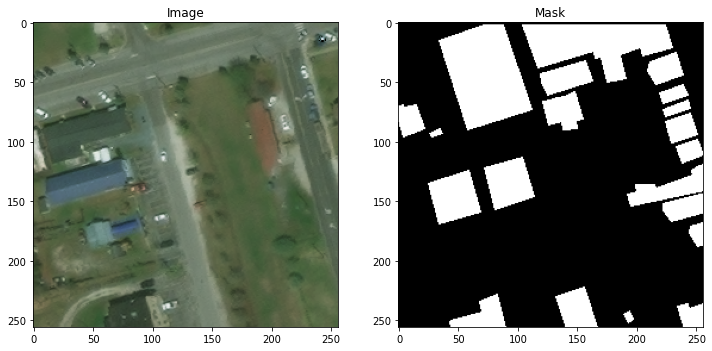

In [8]:
################################################################
#Get an understanding by looking at a few random images and masks 

train_img_dir = "/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/train_images/train/"
train_mask_dir = "/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/train_masks/train/"

img_list = os.listdir(train_img_dir)
msk_list = os.listdir(train_mask_dir)

num_images = len(os.listdir(train_img_dir))


img_num = random.randint(0, num_images-1)

img_for_plot = cv2.imread(train_img_dir+img_list[img_num], 1)
img_for_plot = cv2.cvtColor(img_for_plot, cv2.COLOR_BGR2RGB)

mask_for_plot =cv2.imread(train_mask_dir+msk_list[img_num], 0)

plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(img_for_plot)
plt.title('Image')
plt.subplot(122)
plt.imshow(mask_for_plot, cmap='gray')
plt.title('Mask')
plt.show()

In [ ]:
# img_list

In [14]:
################################################################

# Define Generator for images and masks so we can read them directly from the drive. 

seed=24
batch_size=8
n_classes=2

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
from keras.utils import to_categorical

#Use this to preprocess input for transfer learning
BACKBONE = 'vgg19'
preprocess_input = sm.get_preprocessing(BACKBONE)

In [ ]:
# #Define a function to perform additional preprocessing after datagen.
# #For example, scale images, convert masks to categorical, etc. 
# def preprocess_data(img, mask, num_class):
#     #Scale images
#     img = scaler.fit_transform(img.reshape(-1, img.shape[-1])).reshape(img.shape)
#     img = preprocess_input(img)  #Preprocess based on the pretrained backbone...
#     #Convert mask to one-hot
#     mask = to_categorical(mask, num_class)
      
#     return (img,mask)


In [15]:
def preprocess_data(img, mask, num_class):
    # Normalize images
    img = img / 255.0
    # Clip mask values to range [0, num_class-1]
    mask = np.clip(mask, 0, num_class-1)
    # Convert mask to one-hot
    mask = to_categorical(mask, num_class)
    return (img, mask)

In [16]:
#Define the generator.
#We are not doing any rotation or zoom to make sure mask values are not interpolated.
#It is important to keep pixel values in mask as 0, 1, 2, 3, .....
from keras.preprocessing.image import ImageDataGenerator


In [17]:
def trainGenerator(train_img_path, train_mask_path, num_class):
    
    img_data_gen_args = dict(horizontal_flip=True,
                      vertical_flip=True,
                      fill_mode='reflect')
    
    image_datagen = ImageDataGenerator(**img_data_gen_args)
    mask_datagen = ImageDataGenerator(**img_data_gen_args)
    
    image_generator = image_datagen.flow_from_directory(
        train_img_path,
        class_mode = None,
        batch_size = batch_size,
        seed = seed)
    
    mask_generator = mask_datagen.flow_from_directory(
        train_mask_path,
        class_mode = None,
        color_mode = 'grayscale',
        batch_size = batch_size,
        seed = seed)
    
    train_generator = zip(image_generator, mask_generator)
    
    for (img, mask) in train_generator:
        img, mask = preprocess_data(img, mask, num_class)
        yield (img, mask)



In [18]:
train_img_path = "/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/train_images/"
train_mask_path = "/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/train_masks/"
train_img_gen = trainGenerator(train_img_path, train_mask_path, num_class=2)

val_img_path = "/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/val_images/"
val_mask_path = "/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/val_masks/"
val_img_gen = trainGenerator(val_img_path, val_mask_path, num_class=2)

#Make sure the generator is working and that images and masks are indeed lined up. 
#Verify generator.... In python 3 next() is renamed as __next__()
x, y = train_img_gen.__next__()

Found 246 images belonging to 1 classes.
Found 246 images belonging to 1 classes.


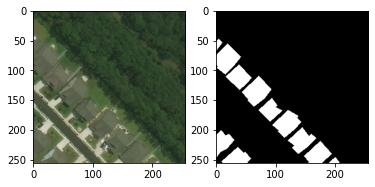

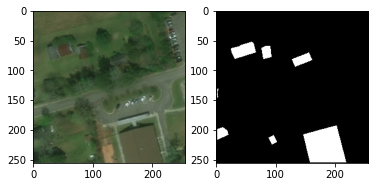

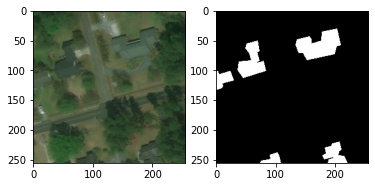

Found 83 images belonging to 1 classes.
Found 83 images belonging to 1 classes.


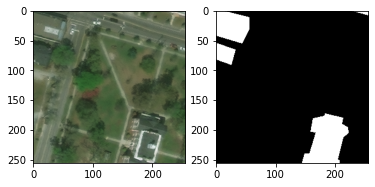

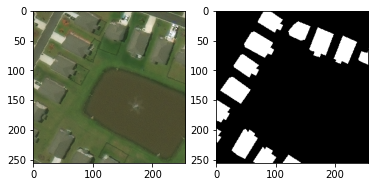

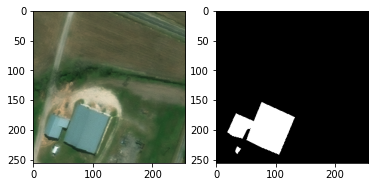

In [19]:


for i in range(0,3):
    image = x[i]
    mask = np.argmax(y[i], axis=2)
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.show()

x_val, y_val = val_img_gen.__next__()

for i in range(0,3):
    image = x_val[i]
    mask = np.argmax(y_val[i], axis=2)
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.show()

In [20]:
###########################################################################
#Define the model metrcis and load model. 

num_train_imgs = len(os.listdir('/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/train_images/train/'))
num_val_images = len(os.listdir('/content/drive/MyDrive/data_for_keras_aug_200/data_for_keras_aug/val_images/val/'))
steps_per_epoch = num_train_imgs//batch_size
val_steps_per_epoch = num_val_images//batch_size


IMG_HEIGHT = x.shape[1]
IMG_WIDTH  = x.shape[2]
IMG_CHANNELS = x.shape[3]

n_classes=2

In [21]:
!pip install torch torchvision torchaudio -f https://download.pytorch.org/whl/cu111/torch_stable.html


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in links: https://download.pytorch.org/whl/cu111/torch_stable.html


In [22]:
import torch
torch.cuda.is_available()

True

In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint

# define the checkpoint
checkpoint_path = '/content/drive/MyDrive/checkpoints_vgg19/checkpoint-{epoch:03d}.hdf5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')



80134624/80134624 [==============================] - 5s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 256, 256, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv2 (Conv2D)          (None, 256, 256, 64  36928       ['block1_conv1[0][0]']           
                             

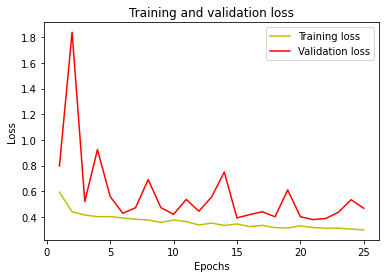

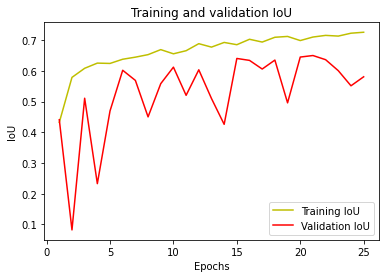

In [24]:
#############################################################################
#Use transfer learning using pretrained encoder in the U-Net
#(make sure you uncomment the preprocess_input part in the
# preprocess_data function above)
################################################################
#Define the model
# define model
model = sm.Linknet(BACKBONE, encoder_weights='imagenet', 
                input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                classes=n_classes, activation='softmax')
model.compile('Adam', loss=sm.losses.categorical_focal_jaccard_loss, metrics=[sm.metrics.iou_score])

#Other losses to try: categorical_focal_dice_loss, cce_jaccard_loss, cce_dice_loss, categorical_focal_loss

#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)
print(model.summary())
print(model.input_shape)
#Fit the model
#history = model.fit(my_generator, validation_data=validation_datagen, steps_per_epoch=len(X_train) // 16, validation_steps=len(X_train) // 16, epochs=100)
#Train the model. 
history=model.fit(train_img_gen,
          steps_per_epoch=steps_per_epoch,
          epochs=25,
          verbose=1,
          validation_data=val_img_gen,
          validation_steps=val_steps_per_epoch,
          callbacks=[checkpoint])

model.save('landcover_100_epochs_RESNET_backbone_batch16.hdf5')

##################################################################
#plot the training and validation IoU and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['iou_score']
val_acc = history.history['val_iou_score']

plt.plot(epochs, acc, 'y', label='Training IoU')
plt.plot(epochs, val_acc, 'r', label='Validation IoU')
plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

#####################################################

In [25]:
from keras.models import load_model

model = load_model("/content/landcover_100_epochs_RESNET_backbone_batch16.hdf5", compile=False)

#batch_size=32 #Check IoU for a batch of images

#Test generator using validation data.

test_image_batch, test_mask_batch = val_img_gen.__next__()

#Convert categorical to integer for visualization and IoU calculation
test_mask_batch_argmax = np.argmax(test_mask_batch, axis=3) 
test_pred_batch = model.predict(test_image_batch)
test_pred_batch_argmax = np.argmax(test_pred_batch, axis=3)

n_classes = 4
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(test_pred_batch_argmax, test_mask_batch_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

#######################################################

1/1 [==============================] - 1s 708ms/step
Mean IoU = 0.67679965


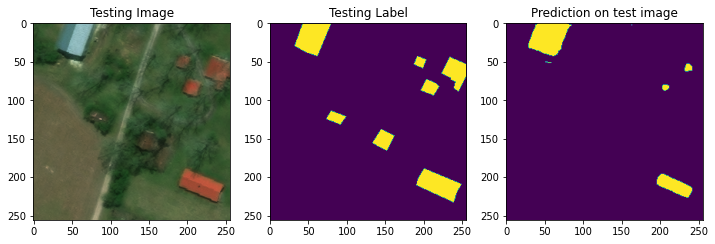

In [45]:
#View a few images, masks and corresponding predictions. 
img_num = random.randint(0, test_image_batch.shape[0]-1)

plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_image_batch[img_num])
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_batch_argmax[img_num])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_pred_batch_argmax[img_num])
plt.show()